In [1]:
from exoatlas import * 

In [ ]:
import arviz as az 

posteriors = {}
for kind in ['any', 'CO2']:
    path = f"https://zenodo.org/records/15858769/files/shoreline-posterior-samples-{kind}-atmosphere.nc?download=1"
    downloaded = download_file(path, cache=True)
    posteriors[kind] = az.from_netcdf(downloaded).posterior

In [ ]:
posteriors

{'any': <xarray.Dataset> Size: 8MB
 Dimensions:      (chain: 4, draw: 50000, log_L_dim_0: 1000, log_f_dim_0: 1000,
                   log_v_dim_0: 1000)
 Coordinates:
   * chain        (chain) int64 32B 0 1 2 3
   * draw         (draw) int64 400kB 0 1 2 3 4 ... 49995 49996 49997 49998 49999
   * log_L_dim_0  (log_L_dim_0) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
   * log_f_dim_0  (log_f_dim_0) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
   * log_v_dim_0  (log_v_dim_0) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
 Data variables:
     ln_w         (chain, draw) float64 2MB ...
     log_f_0      (chain, draw) float64 2MB ...
     p            (chain, draw) float64 2MB ...
     q            (chain, draw) float64 2MB ...
     w            (chain, draw) float64 2MB ...
 Attributes:
     created_at:                 2025-07-02T00:05:03.926423+00:00
     arviz_version:              0.21.0
     inference_library:          numpyro
     inference_library_version:  0.18.0,
 'CO

In [ ]:
def log_f_shoreline(log_f_0=0.0, p=0.0, q=0.0, log_v=0, log_L=0):
    return log_f_0 + p * log_v + q * log_L


def probability_of_atmosphere(
    log_f_0=1.0, p=4.0, q=0.0, ln_w=0, log_v=0, log_L=0, log_f=0
):
    distance_from_shoreline = log_f - log_f_shoreline(
        log_f_0=log_f_0, p=p, q=q, log_v=log_v, log_L=log_L
    )
    width_of_shoreline = np.exp(ln_w)
    return 1 / (1 + np.exp(distance_from_shoreline / width_of_shoreline))

In [ ]:
np.random.randint(0, 5, 100)

array([4, 3, 0, 3, 3, 4, 1, 1, 0, 1, 3, 0, 2, 3, 3, 3, 1, 3, 0, 2, 3, 2,
       3, 4, 1, 3, 2, 3, 0, 0, 4, 0, 4, 1, 0, 3, 2, 3, 0, 3, 3, 2, 1, 1,
       2, 3, 1, 0, 0, 3, 0, 2, 1, 1, 0, 3, 2, 1, 2, 1, 4, 1, 2, 3, 0, 3,
       1, 0, 2, 1, 0, 1, 3, 2, 1, 1, 0, 0, 1, 3, 1, 2, 1, 3, 0, 1, 3, 4,
       4, 2, 2, 1, 4, 1, 4, 4, 1, 1, 4, 3])

In [ ]:
from astropy.uncertainty import normal, Distribution

def calculate_probability_of_atmosphere(
    log_f=0.0,
    log_v=0.0,
    log_L=0.0,
    log_f_uncertainty=0.0,
    log_v_uncertainty=0.0,
    log_L_uncertainty=0.0,
    N=10000,
    kind="any",
):
    '''
    Calculate the probability a planet has an atmosphere.

    This calculates the probability that one or more planet 
    has an atmosphere, according to the probabilistic 
    cosmic shoreline model of Berta-Thompson et al. (2025)
    (https://ui.adsabs.harvard.edu/abs/2025arXiv250702136B/). 
    It generates samples of the calculated probability, 
    including uncertainties propagated from the shoreline
    parameter uncertainties and, if provided, planet 
    measurement uncertainties. 

    Predictors x=(f, v, L) must be provided as log10(x), 
    where x has been scaled relative to the Earth/Sun.

    If needed, to calculate uncertainties on the log10 
    quantities, use something like the following

    `log_x_uncertainty = x_uncertainty/x/np.log(10)`

    which can be derived from standard error propagation. 

    Parameters 
    ----------
    log_f : float, np.array, astropy.units.Quantity
        The bolometric instellation a planet receives,
        expressed as log10[(flux)/(flux at Earth)]
    log_v : float, np.array, astropy.units.Quantity 
        The escape velocity of a planet, relative to Earth, 
        expressed as log10[(escape velocity)/(escape velocity of Earth)]
    log_L : float, np.array, astropy.units.Quantity 
        The stellar luminosity relative to the Sun, 
        expressed as log10[(stellar luminosity)/(solar luminosity)]
    log_f_uncertainty : float, np.array, astropy.units.Quantity 
        The 1-sigma uncertainty on log10[(flux)]
    log_v_uncertainty : float, np.array, astropy.units.Quantity
        The 1-sigma uncertainty on log10[(escape velocity)]
    log_L_uncertainty : float, np.array, astropy.units.Quantity
        The 1-sigma uncertainty on log10[(stellar luminosity)]
    N : int 
        The number of probability samples to produce.
    kind : str
        The kind of shoreline model to use, from the results 
        in Berta-Thompson et al. (2025). Options are: 
            - 'any' = a shoreline inferred from the presence 
            of any type of  atmosphere or surface volatiles 
            - 'CO2' = a shoreline inferred only from planets
            warm enough for CO2 to be gaseous (and not so hot 
            to require a global magma ocean)

    Returns 
    -------
    probability : astropy.uncertainty.Distribution
        The calculated probability of having an atmosphere, 
        as an astropy.uncertainty.Distribution object 
        (see https://docs.astropy.org/en/stable/uncertainty/index.html)
        that will have the same shape as the input predictors.
        Here are a few ways you might use one of these distributions? 

        ```
        p = calculate_probability_of_atmosphere(3.0, 0.0, 0.0)
        print(f'The mean probability is {p.pdf_mean()}')
        print(f'The median probability is {p.pdf_median()}')
        plt.figure(figsize=(8,3))
        plt.hist(p.distribution, bins=np.linspace(0, 1, 101))
        plt.xlabel('$\sf p_{atmosphere}$')
        plt.yticks([])
        plt.xlim(0, 1)
        ```
    '''


    # make sure

    # draw N random samples from the posterior for the parameters
    po = posteriors[kind]
    N_sampled = np.size(po["p"])
    i = np.random.randint(0, N_sampled, N)
    parameters = {
        k: Distribution(np.array(po[k]).flatten()[i])
        for k in ["log_f_0", "p", "q", "ln_w"]
    }

    # make astropy Distributions with uncertainties    
    if log_f_uncertainty > 0:
        log_f = normal(log_f, log_f_uncertainty, N)
    if log_v_uncertainty > 0:
        log_v = normal(log_v, log_v_uncertainty, N)
    if log_L_uncertainty > 0:
        log_L = (log_L, log_L_uncertainty, N)

    # calculate (distributions of) the probability of an atmosphere
    p = probability_of_atmosphere(
        log_v=log_v, log_L=log_L, log_f=log_f, **parameters
    )
    return p

The mean probability is [0.99683049 0.91710134 0.36560996]
The median probability is [0.99808457 0.93734885 0.31561254]


(0.0, 1.0)

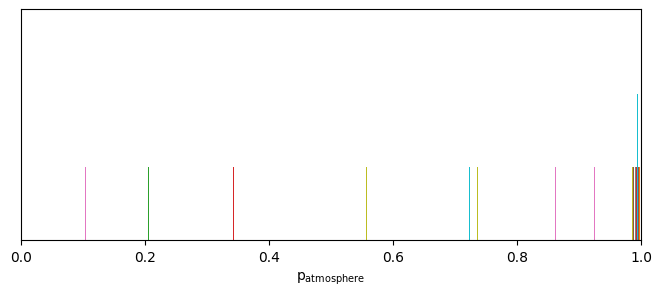

In [ ]:
p = calculate_probability_of_atmosphere(np.array([1,2,3.0]), np.zeros(3), np.zeros(3))
print(f'The mean probability is {p.pdf_mean()}')
print(f'The median probability is {p.pdf_median()}')
plt.figure(figsize=(8,3))
for p_per_planet in p.distribution:
    plt.hist(p.distribution, bins=np.linspace(0, 1, 101))
plt.xlabel('$\sf p_{atmosphere}$')
plt.yticks([])
plt.xlim(0, 1)

In [ ]:
for p_per_planet in p.distribution:
    print(p_per_planet)

[0.99996598 0.99779377 0.99500149 ... 0.99973328 0.996505   0.99301829]
[0.97281373 0.97177228 0.82919777 ... 0.80703702 0.95678041 0.89506531]
[0.04174693 0.72379641 0.10586425 ... 0.00464499 0.63219387 0.338421  ]


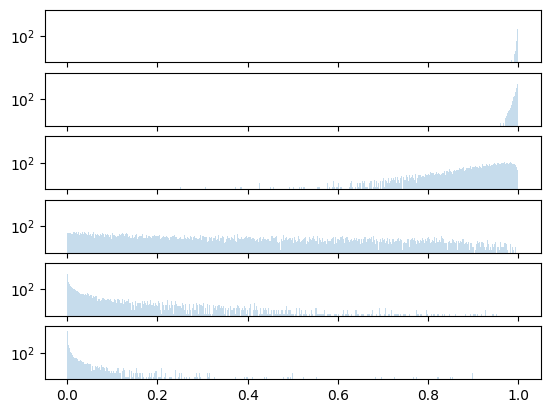

In [ ]:
p = calculate_probability_of_atmosphere(log_f=np.arange(0, 6))
fi, ax = plt.subplots(p.size, 1, sharex=True, sharey=True)
for _, a in zip(p, ax):
    plt.sca(a)
    plt.hist(_.distribution, bins=np.linspace(0, 1, 1000), alpha=0.25)
    plt.yscale('log')


In [ ]:
for k in ['LTT1445Ac', 'GJ 3929 b', 'LTT 1445 A b', 'LHS 1140 b']:
    e = t[k]
    p_samples = probability_of_atmosphere(log_f=jnp.log10(e.relative_instellation()[0]), 
                              log_L=jnp.log10(e.stellar_luminosity().to_value('L_sun')[0]),
                              log_v=jnp.log10(e.relative_escape_velocity()[0]),
                              **sampled_parameters
                              )
    po[f'probability-{k}'] = ['chain','draw'], p_samples*100

NameError: name 't' is not defined